# Task 02: Advanced Data Cleaning and Preprocessing

## Machine Learning Internship

### Dataset
Adult Census Income Dataset

### Objective
The objective of this project is to clean and preprocess the Adult Census Income dataset by handling missing values, duplicate records, outliers, categorical variables, feature scaling, and data validation before using it for machine learning.

## Step 1: Import Required Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

## Step 2 : Load the Dataset

In [25]:
from google.colab import files

uploaded = files.upload()

Saving adult.csv to adult (1).csv


In [26]:
df = pd.read_csv("adult.csv")

In [27]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Step 3 : Explore the Dataset

In [28]:
df.shape

(32561, 15)

In [12]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [30]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## Step 4 : Check Missing Values

In [31]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [32]:
df.isnull().sum().sort_values(ascending=False)

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


## Step 5 : Identify Missing Values Represented by '?'

In [33]:
df.isin(['?']).sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


## Step 6 : Replace '?' with NaN

In [34]:
df.replace('?', np.nan, inplace=True)

## Step 7 : Verify Missing Values After Replacement

In [35]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


## Step 8 : Analyze Missing Values Before Treatment

In [36]:
missing_values = df.isnull().sum()

missing_values

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


In [37]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

,0
age,0.000000
workclass,5.638647
fnlwgt,0.000000
education,0.000000
education.num,0.000000
marital.status,0.000000
occupation,5.660146
relationship,0.000000
race,0.000000
sex,0.000000


In [38]:
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_summary

,Missing Values,Percentage
age,0,0.000000
workclass,1836,5.638647
fnlwgt,0,0.000000
education,0,0.000000
education.num,0,0.000000
marital.status,0,0.000000
occupation,1843,5.660146
relationship,0,0.000000
race,0,0.000000
sex,0,0.000000


## Step 9 : Missing Value Summary

In [39]:
missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
occupation,1843,5.660146
workclass,1836,5.638647
native.country,583,1.790486
fnlwgt,0,0.000000
education,0,0.000000
education.num,0,0.000000
age,0,0.000000
marital.status,0,0.000000
relationship,0,0.000000
sex,0,0.000000


## Step 10 : Visualize Missing Values

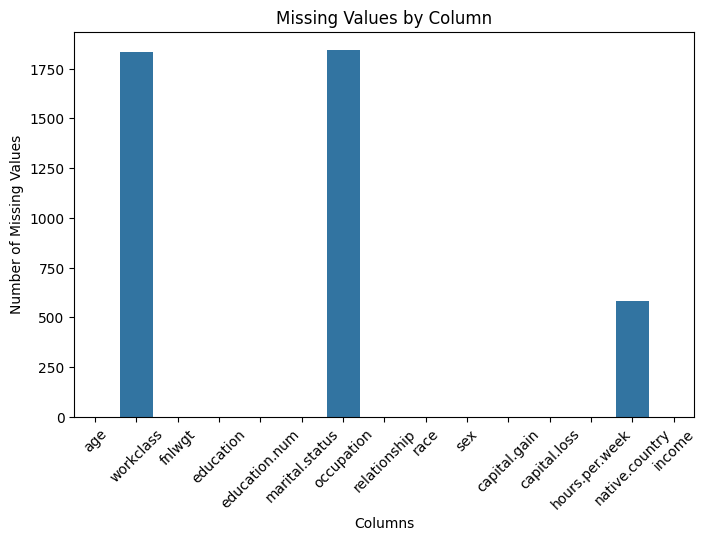

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=missing_summary.index,
    y=missing_summary["Missing Values"]
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)

plt.show()

## Step 11 : Handle Missing Values

In [45]:
df["workclass"].fillna(df["workclass"].mode()[0], inplace=True)

df["occupation"].fillna(df["occupation"].mode()[0], inplace=True)

df["native.country"].fillna(df["native.country"].mode()[0], inplace=True)

## Step 12 : Verify Missing Values After Treatment


In [46]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


## Step 13 : Check Duplicate Records

In [47]:
df.duplicated().sum()

np.int64(24)

## Step 14 : Remove Duplicate Records

In [48]:
df.drop_duplicates(inplace=True)

## Step 15 : Verify Duplicate Removal

In [49]:
df.duplicated().sum()

np.int64(0)

## Step 16 : Detect Outliers Using Box Plot

In [50]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

numerical_columns

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')

## Step 17 : Visualize Outliers

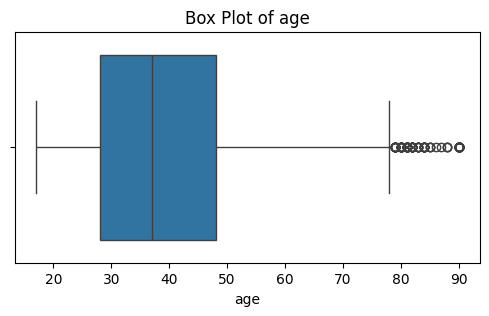

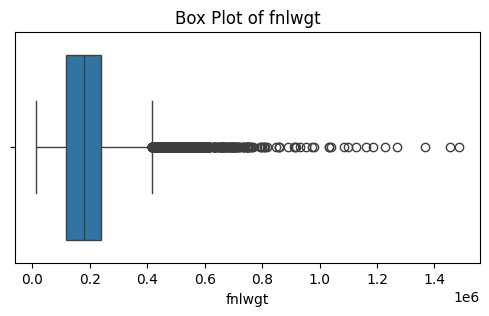

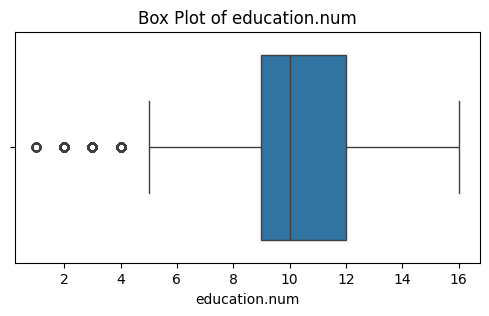

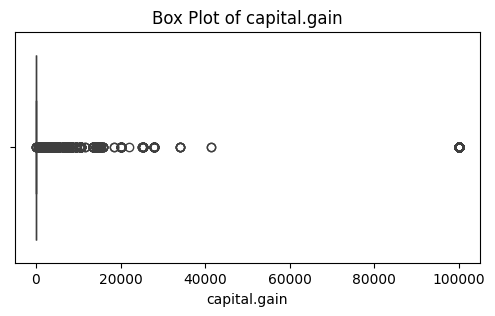

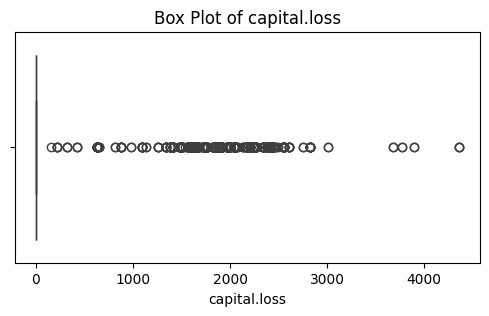

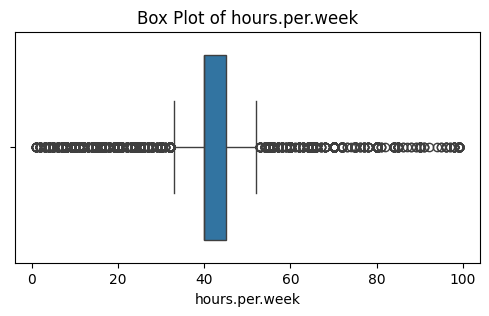

In [51]:
for column in numerical_columns:
    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[column])

    plt.title(f"Box Plot of {column}")

    plt.show()

## Step 20 : Detect Outliers Using IQR Method

In [52]:
Q1 = df["age"].quantile(0.25)

Q3 = df["age"].quantile(0.75)

IQR = Q3 - Q1

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)

Q1 : 28.0
Q3 : 48.0
IQR : 20.0


## Step 21 : Calculate Outlier Bounds

In [53]:
lower_bound = Q1 - (1.5 * IQR)

upper_bound = Q3 + (1.5 * IQR)

print("Lower Bound :", lower_bound)
print("Upper Bound :", upper_bound)

Lower Bound : -2.0
Upper Bound : 78.0


## Step 22 : Identify Outliers

In [54]:
outliers = df[
    (df["age"] < lower_bound) |
    (df["age"] > upper_bound)
]

outliers

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
118,83,Self-emp-inc,153183,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,2392,55,United-States,>50K
128,81,Private,177408,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,2377,26,United-States,>50K
199,90,Private,51744,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,2206,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31939,82,Self-emp-not-inc,71438,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,20,United-States,<=50K
32305,90,Private,313749,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,25,United-States,<=50K
32468,85,Private,98611,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,3,Poland,<=50K
32500,82,Private,403910,HS-grad,9,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,3,United-States,<=50K


In [55]:
len(outliers)

142

In [56]:
outliers.shape

(142, 15)

## Step 23 : One-Hot Encoding

### Purpose

Machine Learning algorithms cannot work directly with categorical (text) data. Therefore, categorical variables must be converted into numerical values before training a model.

### Why One-Hot Encoding?

We used **One-Hot Encoding** because most categorical features in this dataset, such as **workclass, occupation, marital.status, relationship, race, sex, and native.country**, are **nominal variables**. These categories have no natural order or ranking.

One-Hot Encoding converts each category into a separate binary (0 or 1) column, allowing the model to treat every category independently.

### Why Not Label Encoding?

Label Encoding assigns numerical values to categories, which may create a false ordinal relationship between them. Since these features are nominal rather than ordinal, **One-Hot Encoding is the more appropriate preprocessing technique.**

In [57]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,native.country_Canada,native.country_China,native.country_Columbia,native.country_Cuba,native.country_Dominican-Republic,native.country_Ecuador,native.country_El-Salvador,native.country_England,native.country_France,native.country_Germany,native.country_Greece,native.country_Guatemala,native.country_Haiti,native.country_Holand-Netherlands,native.country_Honduras,native.country_Hong,native.country_Hungary,native.country_India,native.country_Iran,native.country_Ireland,native.country_Italy,native.country_Jamaica,native.country_Japan,native.country_Laos,native.country_Mexico,native.country_Nicaragua,native.country_Outlying-US(Guam-USVI-etc),native.country_Peru,native.country_Philippines,native.country_Poland,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,income_>50K
0,90,77053,9,0,4356,40,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,82,132870,9,0,4356,18,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,66,186061,10,0,4356,40,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,54,140359,4,0,3900,40,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,Fal

In [58]:
df_encoded.shape

(32537, 98)

## Step 25 : Feature Scaling

### Purpose

Machine Learning models perform better when numerical features are on a similar scale. Some features may have very small values while others have very large values.

Feature Scaling standardizes numerical features so that each feature contributes equally during model training.

In this task, **StandardScaler** is used to scale the numerical features.

In [59]:
from sklearn.preprocessing import StandardScaler

In [60]:
scaler = StandardScaler()

In [61]:
numerical_columns = df_encoded.select_dtypes(include=["int64", "float64"]).columns

In [62]:
df_encoded[numerical_columns] = scaler.fit_transform(
    df_encoded[numerical_columns]
)

## Step 26 : Verify Scaled Data

### Purpose

To verify that numerical features have been successfully standardized.

In [63]:
df_encoded.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,native.country_Canada,native.country_China,native.country_Columbia,native.country_Cuba,native.country_Dominican-Republic,native.country_Ecuador,native.country_El-Salvador,native.country_England,native.country_France,native.country_Germany,native.country_Greece,native.country_Guatemala,native.country_Haiti,native.country_Holand-Netherlands,native.country_Honduras,native.country_Hong,native.country_Hungary,native.country_India,native.country_Iran,native.country_Ireland,native.country_Italy,native.country_Jamaica,native.country_Japan,native.country_Laos,native.country_Mexico,native.country_Nicaragua,native.country_Outlying-US(Guam-USVI-etc),native.country_Peru,native.country_Philippines,native.country_Poland,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,income_>50K
0,3.770003,-1.067955,-0.420679,-0.145975,10.589625,-0.035664,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,3.183397,-0.539159,-0.420679,-0.145975,10.589625,-1.817516,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,2.010185,-0.035241,-0.031815,-0.145975,10.589625,-0.035664,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,1.

## Step 27 : Data Validation

### Purpose

To ensure that the dataset is completely cleaned and ready for machine learning.

This step verifies that:

- Missing values have been handled.
- Duplicate records have been removed.
- The dataset has been successfully preprocessed.

In [64]:
print("Missing Values:", df_encoded.isnull().sum().sum())

print("Duplicate Records:", df_encoded.duplicated().sum())

print("Dataset Shape:", df_encoded.shape)

Missing Values: 0
Duplicate Records: 0
Dataset Shape: (32537, 98)


# Final Summary

## Objective

The objective of this task was to clean and preprocess the Adult Census Income dataset so that it becomes suitable for machine learning.

## Summary of Work Performed

The following preprocessing steps were completed:

- Loaded and explored the dataset.
- Identified missing values.
- Filled missing values using Mode for categorical features.
- Detected and removed duplicate records.
- Visualized outliers using Box Plots.
- Applied the IQR method to identify potential outliers.
- Converted categorical variables into numerical format using One-Hot Encoding.
- Standardized numerical features using StandardScaler.
- Validated the final dataset to ensure there were no missing values or duplicate records.

## Final Outcome

The dataset is now clean, consistent, and ready for machine learning model development.

# Key Insights

- The dataset contained missing values mainly in **workclass**, **occupation**, and **native.country**.
- Mode imputation was selected because these were categorical variables.
- Duplicate records were identified and removed successfully.
- Several numerical features contained outliers, which were analyzed using Box Plots and the IQR method.
- One-Hot Encoding was chosen because the categorical variables were nominal.
- StandardScaler was applied to numerical features to improve model performance.
- The final dataset contains **32,537 records** and **98 features**, making it suitable for machine learning.